# 01. EDA: 세 배치의 수명과 초기 신호

과제의 EDA 질문 5개를 Batch 1·2·3에 각각 적용하고, 모델링 결정과 연결합니다.
분석 단위는 셀 1개입니다. 이 노트북은 `data/processed/`의 중간 파일만 읽으므로 원본 MAT 파일 없이 실행됩니다.
수명 라벨은 Q1에서는 제공 라벨과 원논문 정제 라벨을 함께 보고, Q2부터는 원논문 정제 라벨(`cycle_life`)을 씁니다.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': '#e6e6e6', 'font.size': 10, 'figure.dpi': 110})
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
C = {'Batch 1': '#1F4E79', 'Batch 2': '#D9822B', 'Batch 3': '#2E8B74'}
B = ['Batch 1', 'Batch 2', 'Batch 3']
from features import build_features
df = build_features()
summary = pd.read_csv(ROOT / 'data/processed/summary.csv.gz')
curves = np.load(ROOT / 'data/processed/qdlin.npz')
L = df[df.in_model].copy()
df.groupby('batch').agg(cells=('cell_uid', 'size'), provided_label=('cycle_life_provided', 'count'),
                        used_in_model=('in_model', 'sum'), policies=('policy', 'nunique'))

,cells,provided_label,used_in_model,policies
batch,,,,
Batch 1,46,46,41,23
Batch 2,47,39,39,20
Batch 3,46,44,40,8


## Q1. Cycle Life 분포는 어떻게 생겼는가?

In [2]:
def life_stats(s):
    s = s.dropna()
    return pd.Series({'n': len(s), 'min': s.min(), 'median': s.median(), 'max': s.max(),
                      'short_<500 (%)': (s < 500).mean() * 100, 'long_>1000 (%)': (s > 1000).mean() * 100,
                      '>=550 (%)': (s >= 550).mean() * 100})
pd.concat({'provided': df.groupby('batch').cycle_life_provided.apply(life_stats).unstack(),
           'paper_rules': df.groupby('batch').cycle_life.apply(life_stats).unstack()}).round(1)

n    min  median     max  short_<500 (%)  long_>1000 (%)  >=550 (%)
            batch                                                                          
provided    Batch 1  46.0  534.0   858.5  1227.0             0.0            21.7       97.8
            Batch 2  39.0  392.0   472.0  1186.0            71.8             7.7       23.1
            Batch 3  44.0  541.0  1005.5  1935.0             0.0            52.3       97.7
paper_rules Batch 1  41.0  534.0   842.0  2237.0             0.0            24.4       97.6
            Batch 2  39.0  392.0   472.0  1186.0            71.8             7.7       23.1
            Batch 3  40.0  541.0   964.5  1935.0             0.0            47.5       97.5

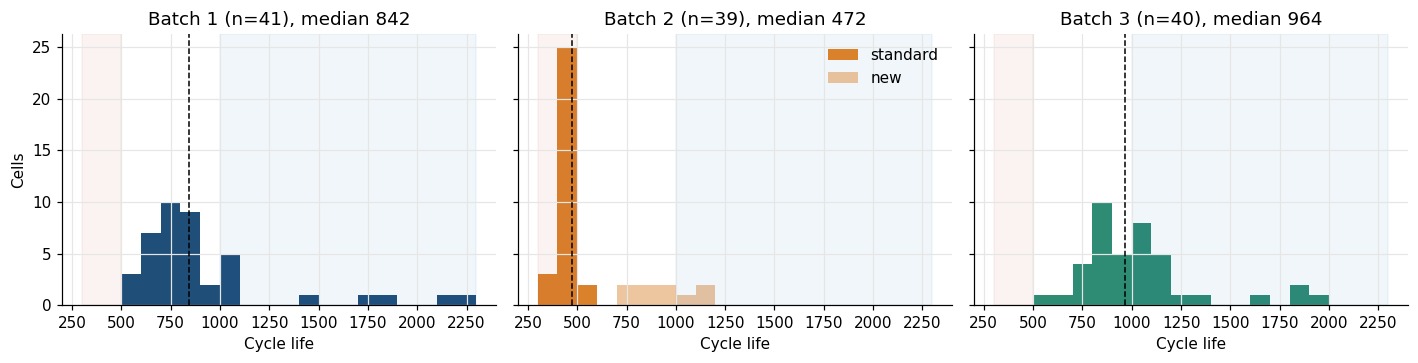

skewness: raw 1.46 -> log10 0.27


,cell_uid,batch,policy,cycle_life,dq_logvar
65,b2c019,Batch 2,6C(60%)-3C,392.0,-3.291958
52,b2c006,Batch 2,3.6C(9%)-5C,393.0,-3.530040
61,b2c015,Batch 2,3.6C(9%)-5C,396.0,-3.516252
67,b2c021,Batch 2,6C(60%)-3C,408.0,-3.326679
76,b2c030,Batch 2,5.6C(26%)-4.5C,412.0,-3.185410


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
bins = np.arange(300, 2350, 100)
for ax, b in zip(axes, B):
    g = L[L.batch == b]
    if b == 'Batch 2':
        for st, a in [('standard', 1), ('new', .45)]:
            ax.hist(g[g.structure == st].cycle_life, bins=bins, color=C[b], alpha=a, label=st)
        ax.legend(frameon=False)
    else:
        ax.hist(g.cycle_life, bins=bins, color=C[b])
    ax.axvline(g.cycle_life.median(), color='k', ls='--', lw=1)
    ax.axvspan(300, 500, color='#C0392B', alpha=.06); ax.axvspan(1000, 2300, color='#1F6FB2', alpha=.06)
    ax.set(title=f'{b} (n={len(g)}), median {g.cycle_life.median():.0f}', xlabel='Cycle life')
axes[0].set_ylabel('Cells'); plt.tight_layout(); plt.show()
from scipy.stats import skew
print('skewness: raw %.2f -> log10 %.2f' % (skew(L.cycle_life), skew(np.log10(L.cycle_life))))
L.nsmallest(5, 'cycle_life')[['cell_uid', 'batch', 'policy', 'cycle_life', 'dq_logvar']]

**해석**: Batch 2는 72%가 500사이클 미만이고, 기존 구조 셀 30개는 모두 Batch 1 최소 수명(534)보다 짧습니다.
Batch 2의 new structure 9셀은 777~1,186으로 따로 떨어져 있어, 한 배치 안에 성격이 다른 두 집단이 섞여 있습니다.
수명은 오른쪽 꼬리 분포이고 log10 변환으로 대칭에 가까워집니다.
유독 짧은 셀은 배치 안에서 ΔQ 분산이 가장 큰 셀이라 측정 오류가 아니라 실제 빠른 열화로 보고 삭제하지 않습니다.

**모델링 결정**: 타깃은 log10(cycle_life), 평가는 원 단위 MAPE. Batch 2는 학습 범위 밖 외삽 평가가 됩니다.

## Q2. 방전 용량은 어떻게 감소하는가?

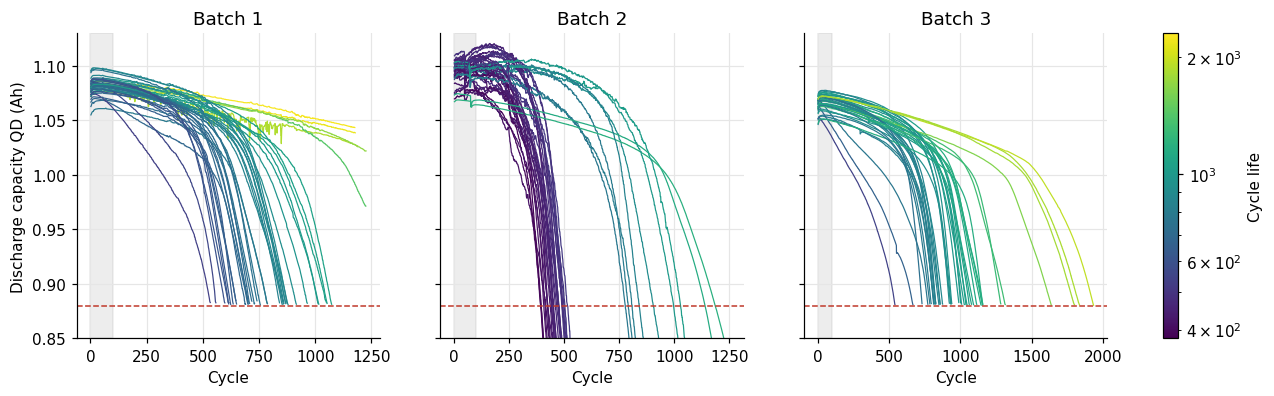

,Batch 1,Batch 2,Batch 3
"rho(qd_mean, life)",0.23,0.12,0.25


In [4]:
import matplotlib.colors as mcolors
norm = mcolors.LogNorm(380, 2300); cm = plt.cm.viridis
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, b in zip(axes, B):
    for _, r in L[L.batch == b].iterrows():
        g = summary[(summary.cell_uid == r.cell_uid) & summary.QD.between(0.8, 1.15)]
        ax.plot(g.cycle, g.QD.rolling(5, center=True, min_periods=1).median(), color=cm(norm(r.cycle_life)), lw=.8)
    ax.axhline(0.88, color='#C0392B', ls='--', lw=1); ax.axvspan(0, 100, color='#888', alpha=.15)
    ax.set(title=b, xlabel='Cycle', ylim=(0.85, 1.13))
axes[0].set_ylabel('Discharge capacity QD (Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm, cm), ax=axes, label='Cycle life', fraction=.02); plt.show()
pd.DataFrame({b: [spearmanr(g.qd_mean, g.cycle_life)[0]] for b, g in L.groupby('batch')}, index=['rho(qd_mean, life)']).round(2)

**해석**: 회색 입력 구간(사이클 1~100)에서는 장·단수명 셀의 용량이 겹칩니다(초기 평균 용량–수명 ρ는 배치 안에서 0.1~0.3).
감소는 일정하지 않고 후반에 급격히 빨라지며(knee), knee는 수명의 약 77% 시점(DAY 1 분석)으로 입력 구간보다 한참 뒤입니다.
Batch 2 기존 구조 셀은 초기 용량이 높고 150~200사이클까지 오히려 오르다가 급락합니다.

**모델링 결정**: knee·기록 길이는 미래 정보라 입력 금지. 용량 값만으로는 부족하므로 방전 곡선 모양(ΔQ)을 핵심 피처로 씁니다.

## Q3. ΔQ(V) 곡선: 초기 사이클에서 차이가 보이는가?

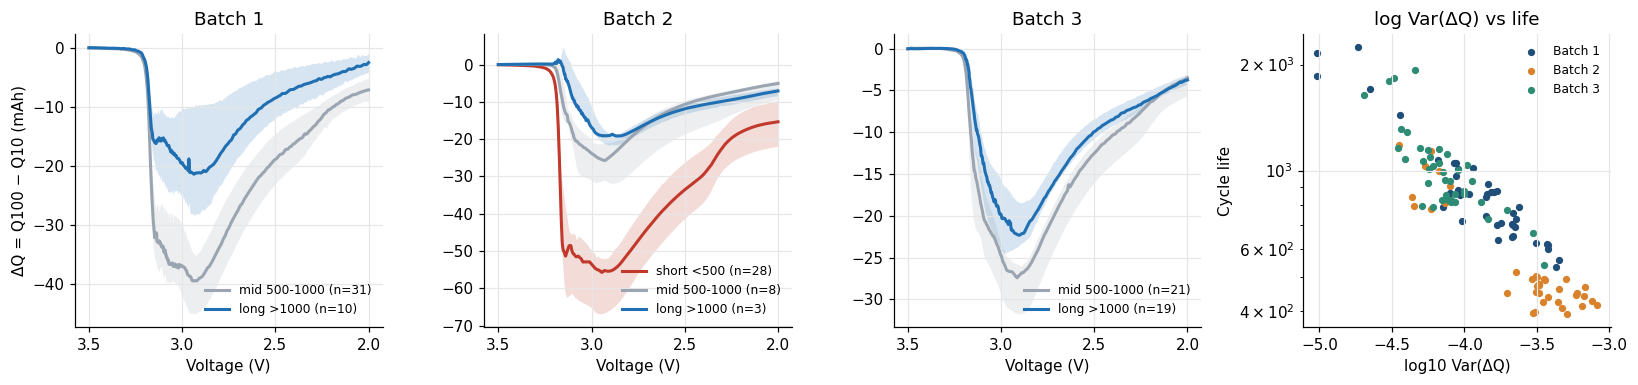

,Batch 1,Batch 2,Batch 3
dq_logvar,-0.88,-0.71,-0.76
dq_logabsmin,-0.85,-0.66,-0.74
dq_mean,0.84,0.70,0.72
dq_skew,-0.58,-0.15,-0.14
dq_kurt,0.24,0.50,0.19
qd_mean,0.23,0.12,0.25


In [5]:
V = curves['voltage']
def grp(x): return 'short <500' if x < 500 else ('long >1000' if x > 1000 else 'mid 500-1000')
GC = {'short <500': '#C0392B', 'mid 500-1000': '#9AA5B1', 'long >1000': '#1F6FB2'}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, b in zip(axes, B):
    g = L[L.batch == b]
    for name, col in GC.items():
        ids = g[g.cycle_life.map(grp) == name].cell_uid
        if len(ids) == 0: continue
        M = np.array([curves[u + '_q100'] - curves[u + '_q10'] for u in ids]) * 1000
        ax.fill_between(V, *np.percentile(M, [25, 75], 0), color=col, alpha=.18, lw=0)
        ax.plot(V, np.median(M, 0), color=col, lw=2, label=f'{name} (n={len(ids)})')
    ax.invert_xaxis(); ax.set(title=b, xlabel='Voltage (V)'); ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel('ΔQ = Q100 − Q10 (mAh)')
ax = axes[3]
for b in B:
    g = L[L.batch == b]; ax.scatter(g.dq_logvar, g.cycle_life, s=14, color=C[b], label=b)
ax.set(yscale='log', xlabel='log10 Var(ΔQ)', ylabel='Cycle life', title='log Var(ΔQ) vs life'); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
stats = ['dq_logvar', 'dq_logabsmin', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_mean']
pd.DataFrame({b: [spearmanr(g[s], g.cycle_life)[0] for s in stats] for b, g in L.groupby('batch')}, index=stats).round(2)

**해석**: 단수명 셀일수록 3.0V 부근의 골이 깊고 넓습니다. 이 모양을 요약한 log10 Var(ΔQ)는 세 배치 모두에서 수명과 강한 음의 상관(ρ −0.71 ~ −0.88)을 보이고,
log–log 평면에서 거의 직선입니다. 최솟값·평균은 같은 정보의 중복이고, 왜도·첨도는 방향은 같지만 Batch 2·3에서 약합니다(|ρ| 0.14~0.50).

**모델링 결정**: log10 Var(ΔQ)를 1순위 피처로, 단일 피처 선형 모델을 핵심 기준선으로 둡니다.

## Q4. 충전 조건(C-rate)과 수명의 관계는?

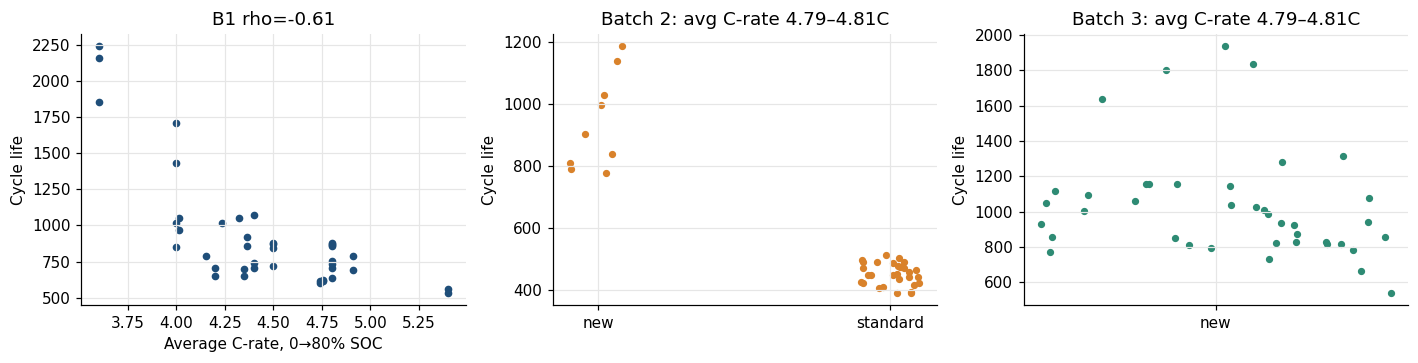

,Batch 1,Batch 2,Batch 3
avg_crate_0_80,-0.61,0.28,-0.16
c_rate_1,-0.49,0.06,-0.16
c_rate_2,0.02,-0.12,-0.11
switch_soc,0.23,0.29,0.41


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
g = L[L.batch == 'Batch 1']
axes[0].scatter(g.avg_crate_0_80, g.cycle_life, color=C['Batch 1'], s=16)
axes[0].set(xlabel='Average C-rate, 0→80% SOC', ylabel='Cycle life', title=f"B1 rho={spearmanr(g.avg_crate_0_80, g.cycle_life)[0]:.2f}")
for ax, b in zip(axes[1:], ['Batch 2', 'Batch 3']):
    g = L[L.batch == b]
    for i, (st, e) in enumerate(g.groupby('structure')):
        ax.scatter(np.full(len(e), i) + np.random.default_rng(0).uniform(-.1, .1, len(e)), e.cycle_life, s=14, color=C[b])
    ax.set_xticks(range(g.structure.nunique())); ax.set_xticklabels(sorted(g.structure.unique()))
    ax.set(title=f'{b}: avg C-rate {g.avg_crate_0_80.min():.2f}–{g.avg_crate_0_80.max():.2f}C', ylabel='Cycle life')
plt.tight_layout(); plt.show()
cols = ['avg_crate_0_80', 'c_rate_1', 'c_rate_2', 'switch_soc']
pd.DataFrame({b: [spearmanr(g[c], g.cycle_life)[0] for c in cols] for b, g in L.groupby('batch')}, index=cols).round(2)

**해석**: Batch 1은 0→80% 평균 C-rate가 3.6~5.4C로 다양하고 고속 충전 셀이 짧습니다.
Batch 2·3는 모든 정책이 10분 충전(평균 약 4.8C)으로 설계되어 총 충전 속도가 같고, Batch 2의 수명 차이는 셀 구조에서 나옵니다.
충전 조건과 수명의 관계는 배치마다 방향이 달라 일반화 근거가 약합니다.

**모델링 결정**: 정책 피처는 기본 셋에서 빼고 보조 실험(F3)으로만 확인합니다. 같은 정책 셀이 학습·검증에 섞이지 않게 정책 단위로 분할합니다.

## Q5. 어떤 신호가 수명과 연관되어 있는가?

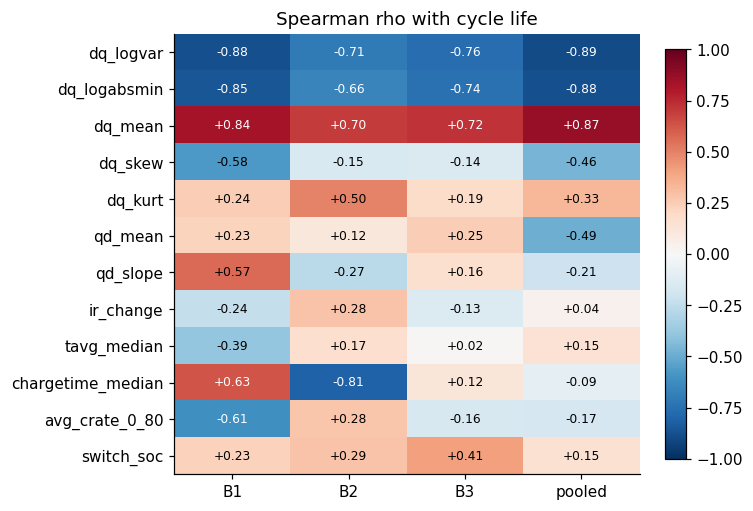

,Batch 1,Batch 2,Batch 3,pooled
dq_logvar,-0.88,-0.71,-0.76,-0.89
dq_logabsmin,-0.85,-0.66,-0.74,-0.88
dq_mean,0.84,0.70,0.72,0.87
dq_skew,-0.58,-0.15,-0.14,-0.46
dq_kurt,0.24,0.50,0.19,0.33
qd_mean,0.23,0.12,0.25,-0.49
qd_slope,0.57,-0.27,0.16,-0.21
ir_change,-0.24,0.28,-0.13,0.04
tavg_median,-0.39,0.17,0.02,0.15
chargetime_median,0.63,-0.81,0.12,-0.09


In [7]:
feats = ['dq_logvar', 'dq_logabsmin', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_mean', 'qd_slope', 'ir_change',
         'tavg_median', 'chargetime_median', 'avg_crate_0_80', 'switch_soc']
corr = pd.DataFrame({b: [spearmanr(g[f], g.cycle_life, nan_policy='omit')[0] for f in feats] for b, g in L.groupby('batch')}, index=feats)
corr['pooled'] = [spearmanr(L[f], L.cycle_life, nan_policy='omit')[0] for f in feats]
fig, ax = plt.subplots(figsize=(6, 5.2))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
for i in range(len(feats)):
    for j in range(4):
        ax.text(j, i, f'{corr.values[i, j]:+.2f}', ha='center', va='center', fontsize=8, color='w' if abs(corr.values[i, j]) > .6 else 'k')
ax.set_xticks(range(4)); ax.set_xticklabels(['B1', 'B2', 'B3', 'pooled']); ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats); ax.grid(False)
ax.set_title('Spearman rho with cycle life'); plt.colorbar(im, ax=ax, fraction=.04); plt.show()
corr.round(2)

**해석**: 세 배치에서 방향과 크기가 일관된 것은 ΔQ 계열뿐입니다.
초기 평균 용량(`qd_mean`)은 배치 안에서 +0.1~+0.3인데 세 배치를 합치면 −0.5로 뒤집힙니다. Batch 2가 초기 용량은 높고 수명은 짧은 배치라서 생기는 배치 효과입니다.
충전시간은 B1 +0.6, B2 −0.8로 방향이 반대입니다. 다중공선성은 `02_feature_engineering`에서 VIF로 확인합니다.

## EDA → 모델링 연결

| EDA 발견 | 모델링 결정 |
|---|---|
| Q1 오른쪽 꼬리 분포, B2 단수명이 학습 범위 밖 | 타깃 log10(cycle_life), 외삽 가능한 선형 계열 중심 |
| Q2 초기 용량이 겹침, knee는 사후 정보 | ΔQ 피처 사용, knee·기록 길이 입력 금지 |
| Q3 log Var(ΔQ)–log 수명 직선, 세 배치 일관 | 1순위 피처, 단일 피처 선형 기준선 |
| Q4 충전 조건 효과가 배치마다 다름 | 정책 피처 제외(보조 실험), 정책 단위 분할 |
| Q5 배치 합치면 허위 상관 | 피처는 배치별 상관으로 판단, 규제 모델 |